# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [115]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [116]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


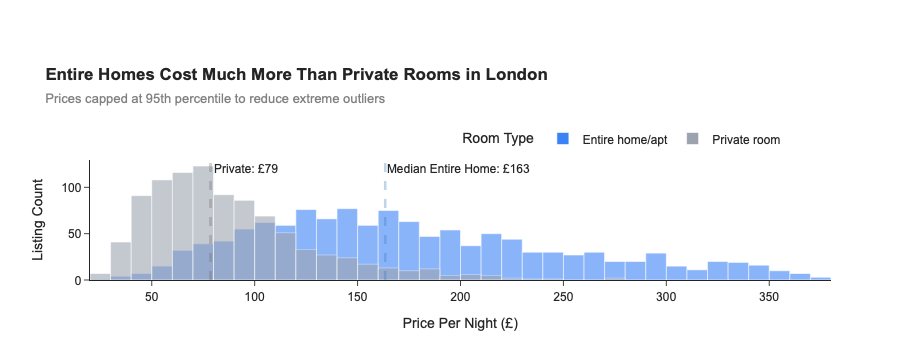

In [117]:
# Task 1
# YOUR CODE HERE
# Task 1
# Histogram: price by room type

# Filter only two room types
df_task1 = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
].copy()

# Calculate medians
med_home = df_task1[df_task1['room_type'] == 'Entire home/apt']['price'].median()
med_private = df_task1[df_task1['room_type'] == 'Private room']['price'].median()

# Create histogram
fig1 = px.histogram(
    df_task1,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    color_discrete_map={
        'Entire home/apt': '#3B82F6',
        'Private room': '#9CA3AF'
    },
    title="<b>Entire Homes Cost Much More Than Private Rooms in London</b><br><span style='font-size:13px;color:gray'>Prices capped at 95th percentile to reduce extreme outliers</span>",
    labels={
        'price': 'Price Per Night (£)',
        'count': 'Listing Count',
        'room_type': 'Room Type'
    },
    template='simple_white'
)

# Median line — Entire home
fig1.add_vline(
    x=med_home,
    line_dash='dash',
    line_color='#2E75B6',
    line_width=3,

    annotation_text=f"Median Entire Home: £{med_home:.0f}",
    annotation_position='top right'
)

# Median line — Private room
fig1.add_vline(
    x=med_private,
    line_dash='dash',
    line_color='#666666',
    line_width=3,

    annotation_text=f"Private: £{med_private:.0f}",
    annotation_position='top right',

    annotation_xshift=1
)

# Layout polish
fig1.update_layout(
    font=dict(family='Arial'),

    legend=dict(
        title='Room Type',
        orientation='h',
        y=1.30,
        x=0.72,
        xanchor='center'
    ),

    yaxis_title='Listing Count',

    margin=dict(
        t=160,
        l=90
    )
)

fig1.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

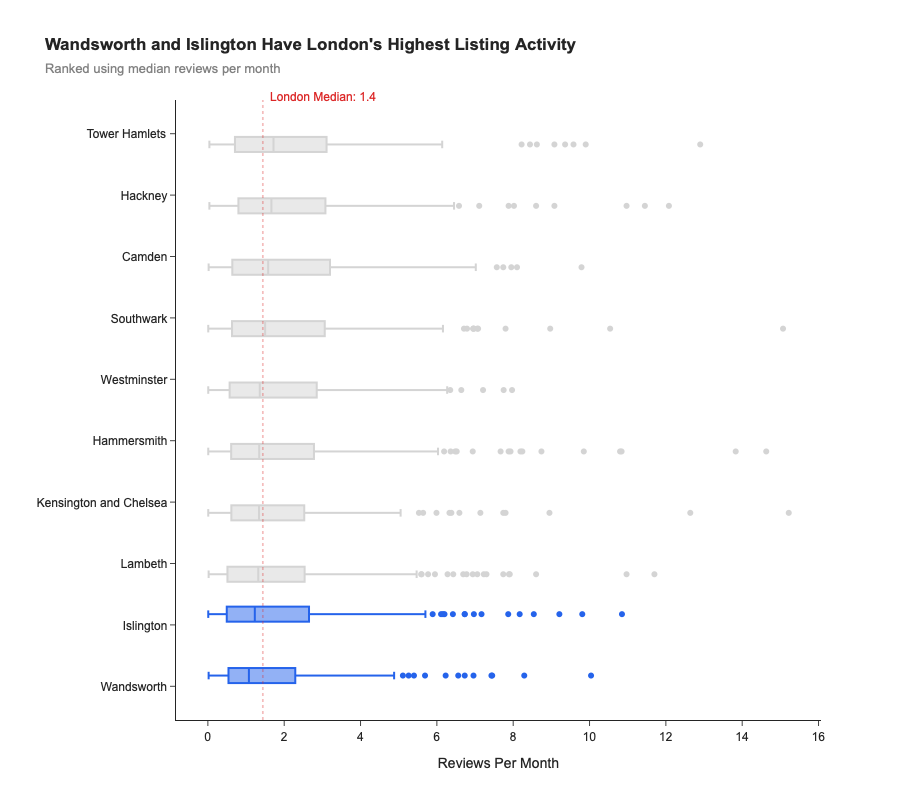

In [118]:
# Task 2
# YOUR CODE HERE
# Task 2
# Box plot: listing activity by borough

# Remove listings with zero reviews
df_active = df_cap[df_cap['reviews_per_month'] > 0].copy()

# Median reviews per borough
borough_stats = (
    df_active.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

sorted_boroughs = borough_stats.index.tolist()

# Top 2 most active boroughs
top_2 = sorted_boroughs[-2:]

# Highlight column
df_active['highlight'] = df_active['neighbourhood'].apply(
    lambda x: 'Top Boroughs' if x in top_2 else 'Other Boroughs'
)

# Create box plot
fig2 = px.box(
    df_active,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    category_orders={'neighbourhood': sorted_boroughs},
    color_discrete_map={
        'Top Boroughs': '#2563EB',
        'Other Boroughs': '#D4D4D4'
    },
    points='outliers',
    orientation='h',
    template='simple_white',
    title=f"<b>{top_2[1]} and {top_2[0]} Have London's Highest Listing Activity</b><br><span style='font-size:13px;color:gray'>Ranked using median reviews per month</span>",
    labels={
        'reviews_per_month': 'Reviews Per Month',
        'neighbourhood': ''
    },
    height=800
)

# Global median line
global_median = df_active['reviews_per_month'].median()

fig2.add_vline(
    x=global_median,
    line_dash='dot',
    line_color='#DC2626',
    line_width=2
)

# Median annotation
fig2.add_annotation(
    x=global_median,
    y=1.02,
    yref='paper',
    text=f"London Median: {global_median:.1f}",
    showarrow=False,
    font=dict(
        color='#DC2626',
        size=12,
        family='Arial'
    ),
    xanchor='left',
    xshift=5
)

# Layout cleanup
fig2.update_layout(
    showlegend=False,
    font=dict(family='Arial'),
    margin=dict(l=160, t=100)
)

fig2.show()